Potensi Energi Baru Terbarukan per Provinsi di Indonesia

Sumber: Our World Data (OWID), ESDM, BPS PRDB.


In [27]:
# STEP 0: Load all files

import pandas as pd
import numpy as np

owid = pd.read_excel("owid-energy-data.xlsx")
capacity = pd.read_csv("province_power_capacity_2025_raw.csv")
geothermal = pd.read_csv("province_geothermal_reserves_2025_raw.csv")
coal = pd.read_csv("province_coal_reserves_2025_raw.csv")
pdrb = pd.read_excel("bps PDRB.xlsx")

print(owid.shape, capacity.shape, geothermal.shape, coal.shape, pdrb.shape)


(23377, 130) (38, 20) (32, 8) (26, 9) (352, 6)


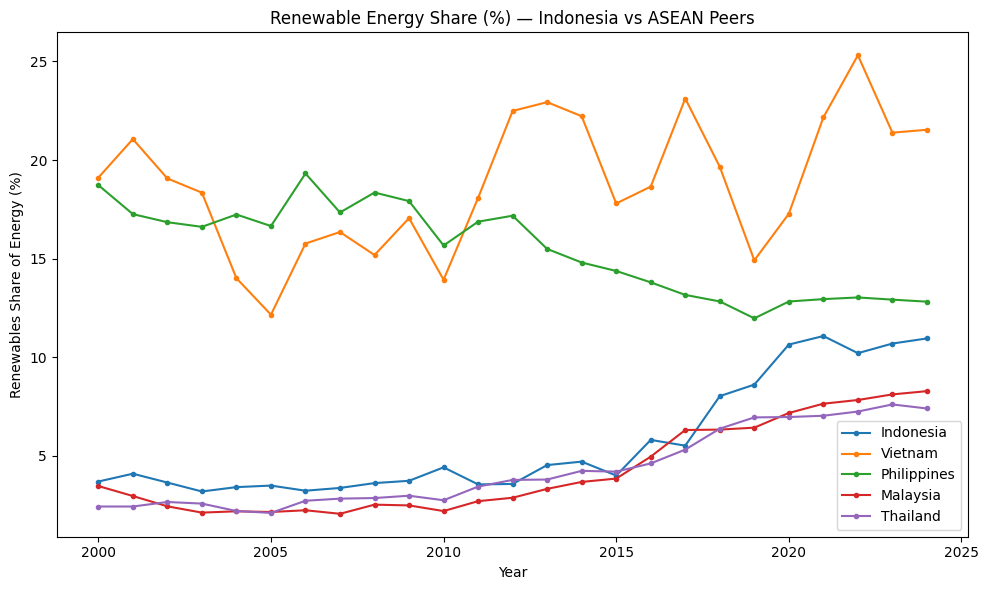

           country  year  renewables_share_energy
22622      Vietnam  2024                21.534109
17493  Philippines  2024                12.818433
9824     Indonesia  2024                10.954190
12051     Malaysia  2024                 8.281804
20683     Thailand  2024                 7.402746


In [28]:
# STEP 1: National/Regional Context (OWID)
import matplotlib.pyplot as plt

asean_compare = ['Indonesia', 'Vietnam', 'Philippines', 'Malaysia', 'Thailand']
owid_asean = owid[
    (owid['country'].isin(asean_compare)) &
    (owid['year'] >= 2000)
][['country', 'year', 'renewables_share_energy']].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
for country in asean_compare:
    subset = owid_asean[owid_asean['country'] == country]
    ax.plot(subset['year'], subset['renewables_share_energy'], marker='o', markersize=3, label=country)

ax.set_title('Renewable Energy Share (%) — Indonesia vs ASEAN Peers')
ax.set_xlabel('Year')
ax.set_ylabel('Renewables Share of Energy (%)')
ax.legend()
plt.tight_layout()
plt.savefig('owid_asean_trend.png', dpi=150)
plt.show()

print(owid_asean[owid_asean['year'] == owid_asean['year'].max()]
      .sort_values('renewables_share_energy', ascending=False))

In [29]:
# STEP 2: Data Inspection

print(capacity.dtypes)
print(capacity['hydro_pp_mw'].unique()[:10])
print(sorted(pdrb['nama_provinsi'].unique()))

province_code                int64
province                    object
hydro_pp_mw                float64
mini_hydro_pp_mw           float64
micro_hydro_pp_mw          float64
geothermal_pp_mw           float64
solar_pp_mw                float64
wind_pp_mw                 float64
biogas_pp_mw               float64
biomass_pp_mw              float64
biofuel_pp_mw                int64
waste_pp_mw                float64
diesel_pp_mw               float64
steam_pp_mw                float64
gas_pp_mw                  float64
coal_gasification_pp_mw      int64
combined_cycle_pp_mw       float64
gas_engine_pp_mw           float64
other_pp_mw                  int64
total_mw                   float64
dtype: object
[  10.   1195.55  243.    114.    492.      0.    277.15  174.6  2056.6
  229.8 ]
['ACEH', 'BALI', 'BANTEN', 'BENGKULU', 'DI YOGYAKARTA', 'DKI JAKARTA', 'GORONTALO', 'JAMBI', 'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR', 'KALIMANTAN BARAT', 'KALIMANTAN SELATAN', 'KALIMANTAN TENGAH', 'KALI

In [30]:
# STEP 3: Replace or clean the column '-' with  0, changes to numeric type
def clean_numeric(df, exclude=('province_code', 'province')):
    df = df.copy()
    for col in df.columns:
        if col in exclude:
            continue
        n_replaced = (df[col] == '-').sum()
        if n_replaced > 0:
            print(f"  [{col}] replaced {n_replaced} '-' value(s) with 0")
        df[col] = df[col].replace('-', 0)
        df[col] = pd.to_numeric(df[col])
    return df

print("Cleaning capacity_clean:")
capacity_clean = clean_numeric(capacity)
print("Cleaning geothermal_clean:")
geothermal_clean = clean_numeric(geothermal)
print("Cleaning coal_clean:")
coal_clean = clean_numeric(coal)

Cleaning capacity_clean:
Cleaning geothermal_clean:
Cleaning coal_clean:


In [31]:
# STEP 4: Mapping the name of province (ID -> EN)

province_mapping = {
    "Aceh": "Aceh",
    "Bali": "Bali",
    "Banten": "Banten",
    "Bengkulu": "Bengkulu",
    "Di Yogyakarta": "Special Region of Yogyakarta",
    "Dki Jakarta": "Special Capital Region of Jakarta",
    "Gorontalo": "Gorontalo",
    "Jambi": "Jambi",
    "Jawa Barat": "West Java",
    "Jawa Tengah": "Central Java",
    "Jawa Timur": "East Java",
    "Sumatera Selatan": "South Sumatera",
    "Sumatera Utara": "North Sumatera",
    "Sumatera Barat": "West Sumatera",
    "Kalimantan Barat": "West Kalimantan",
    "Kalimantan Selatan": "South Kalimantan",
    "Kalimantan Tengah": "Central Kalimantan",
    "Kalimantan Timur": "East Kalimantan",
    "Kalimantan Utara": "North Kalimantan",
    "Kepulauan Bangka Belitung": "Bangka Belitung Islands",
    "Kepulauan Riau": "Riau Islands",
    "Lampung": "Lampung",
    "Maluku": "Maluku",
    "Maluku Utara": "North Maluku",
    "Nusa Tenggara Barat": "West Nusa Tenggara",
    "Nusa Tenggara Timur": "East Nusa Tenggara",
    "Papua": "Papua",
    "Papua Barat": "West Papua",
    "Papua Barat Daya": "Southwest Papua",
    "Papua Selatan": "South Papua",
    "Papua Tengah": "Central Papua",
    "Papua Pegunungan": "Papua Mountains",
    "Riau": "Riau",
    "Sulawesi Barat": "West Sulawesi",
    "Sulawesi Selatan": "South Sulawesi",
    "Sulawesi Tengah": "Central Sulawesi",
    "Sulawesi Tenggara": "Southeast Sulawesi",
    "Sulawesi Utara": "North Sulawesi",
}


# Change and normalize the format of the title
# do normalize before the mapping, that would be avoid the case-sensitive

pdrb['normalized_province_name'] = pdrb['nama_provinsi'].str.title()
pdrb['province_name_en'] = pdrb['normalized_province_name'].map(province_mapping)

gagal_mapping = pdrb[pdrb['province_name_en'].isna()]['nama_provinsi'].unique()
print("Provinsi Gagal Mapping: ", gagal_mapping)


Provinsi Gagal Mapping:  []


In [32]:
# STEP 5: Validated the total vs value from Official Handbook ESDM 2025
# Source: Handbook of Energy & Economic Statistics of Indonesia (ESDM), 2025 edition
# Accessed: [2026-08-21]
# URL/reference: [https://www.esdm.go.id/assets/media/content/content-handbook-of-energy-and-economic-statistics-of-indonesia-2025.pdf, https://www.esdm.go.id/en/publication/handbook-of-energy-economic-statistics-of-indonesia-heesi]

official_totals = {
    'capacity_mw': 107498.89,
    'geothermal_mw': 23203,
    'coal_reserve_mt': 33250.10,
}

computed = {
    'capacity_mw': capacity_clean['total_mw'].sum(),
    'geothermal_mw': geothermal_clean['total_mw'].sum(),
    'coal_reserve_mt': coal_clean['reserve_total_mt'].sum(),
}

for k in official_totals:
  diff_pct = abs(computed[k] - official_totals[k]) / official_totals[k] * 100
  status = "OK" if diff_pct < 0.1 else "CHECK!"
  print(f"{k}: computed={computed[k]:,.2f} | official={official_totals[k]:,.2f} | diff={diff_pct:,.3f}% [{status}]")

capacity_mw: computed=107,498.89 | official=107,498.89 | diff=0.000% [OK]
geothermal_mw: computed=23,204.00 | official=23,203.00 | diff=0.004% [OK]
coal_reserve_mt: computed=33,250.11 | official=33,250.10 | diff=0.000% [OK]


In [33]:
# STEP 6: Derived columns: renewable_capacity_mw, renewable_share_pct

renewable_cols = ['hydro_pp_mw', 'mini_hydro_pp_mw', 'micro_hydro_pp_mw', 'geothermal_pp_mw',
                   'solar_pp_mw', 'wind_pp_mw', 'biogas_pp_mw', 'biomass_pp_mw',
                   'biofuel_pp_mw', 'waste_pp_mw']
fossil_cols = ['diesel_pp_mw', 'steam_pp_mw', 'gas_pp_mw', 'coal_gasification_pp_mw',
               'combined_cycle_pp_mw', 'gas_engine_pp_mw']

capacity_clean['renewable_capacity_mw'] = capacity_clean[renewable_cols].sum(axis=1)
capacity_clean['fossil_capacity_mw'] = capacity_clean[fossil_cols].sum(axis=1)
capacity_clean['renewable_share_pct'] = (
    capacity_clean['renewable_capacity_mw'] / capacity_clean['total_mw'] * 100
).round(2)

print(capacity_clean[['province', 'renewable_share_pct']]
      .sort_values('renewable_share_pct', ascending=False).head(10).to_string(index=False))

                    province  renewable_share_pct
                    Bengkulu                60.66
                       Jambi                52.94
Special Region of Yogyakarta                50.48
              North Sumatera                49.15
               West Sumatera                49.11
                     Lampung                46.23
          Central Kalimantan                40.16
              South Sulawesi                38.10
               West Sulawesi                36.60
              North Sulawesi                32.76


In [34]:
# STEP 7: Merge the capacity of geothermal + coal + PDRB | validate merge keys before merging
assert capacity_clean['province'].is_unique, "Duplicate province in capacity_clean!"
assert geothermal_clean['province'].is_unique, "Duplicate province in geothermal_clean!"
assert coal_clean['province'].is_unique, "Duplicate province in coal_clean!"

province_merged = (
    capacity_clean
    .merge(geothermal_clean[['province', 'total_mw']]
           .rename(columns={'total_mw': 'geothermal_reserve_mw'}), on='province', how='left')
    .merge(coal_clean[['province', 'reserve_total_mt']]
           .rename(columns={'reserve_total_mt': 'coal_reserve_mt'}), on='province', how='left')
)

province_merged[['geothermal_reserve_mw', 'coal_reserve_mt']] = (
    province_merged[['geothermal_reserve_mw', 'coal_reserve_mt']].fillna(0)
)

pdrb_latest = pdrb[pdrb['tahun'] == pdrb['tahun'].max()]
province_merged = province_merged.merge(
    pdrb_latest[['province_name_en', 'pdrb_per_kapita']]
    .rename(columns={'province_name_en': 'province'}),
    on='province', how='left'
)

print(f"Shape: {province_merged.shape}")
print("Missing values per column:")
print(province_merged.isna().sum()[province_merged.isna().sum() > 0])
print(province_merged[province_merged['pdrb_per_kapita'].isna()]['province'])

Shape: (38, 26)
Missing values per column:
Series([], dtype: int64)
Series([], Name: province, dtype: object)


In [35]:
# STEP 8: Gap analysis - geothermal_untapped_mw + Top 5

province_merged['geothermal_untapped_mw'] = (
    province_merged['geothermal_reserve_mw'] - province_merged['geothermal_pp_mw']
).clip(lower=0)

top5 = province_merged.sort_values('geothermal_untapped_mw', ascending=False).head(5)
print(top5[['province', 'geothermal_reserve_mw', 'geothermal_pp_mw', 'geothermal_untapped_mw', 'pdrb_per_kapita']].to_string(index=False))

     province  geothermal_reserve_mw  geothermal_pp_mw  geothermal_untapped_mw  pdrb_per_kapita
    West Java                 4420.0           1260.68                 3159.32         59864.61
West Sumatera                 1648.0             89.25                 1558.75         59548.83
      Lampung                 1732.0            229.00                 1503.00         55009.07
 Central Java                 1341.0             72.80                 1268.20         50823.64
    East Java                 1299.0             34.00                 1265.00         80855.92


Pearson correlation (PDRB per kapita vs Renewable Share %): r = -0.252, p = 0.1277


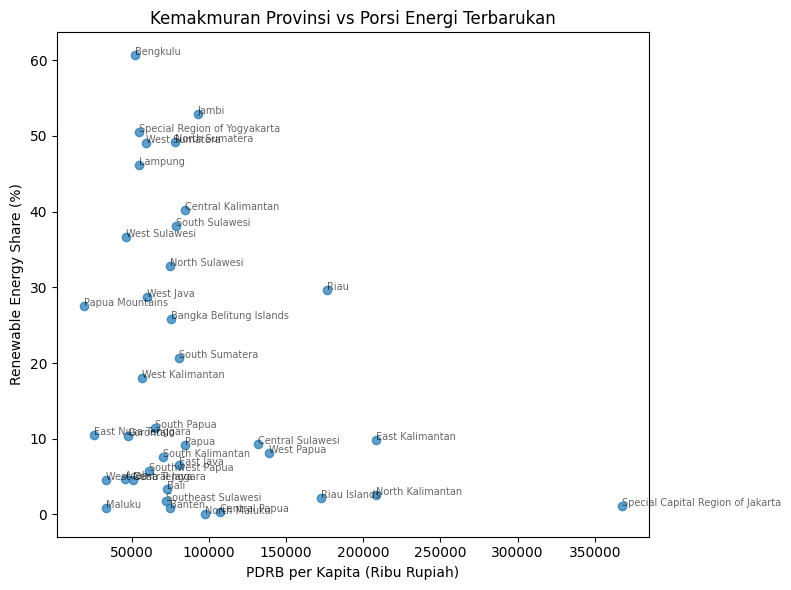

In [36]:
# STEP 9:
from scipy import stats

x = province_merged['pdrb_per_kapita']
y = province_merged['renewable_share_pct']

r, p_value = stats.pearsonr(x, y)
print(f"Pearson correlation (PDRB per kapita vs Renewable Share %): r = {r:.3f}, p = {p_value:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.7)
for _, row in province_merged.iterrows():
    ax.annotate(row['province'], (row['pdrb_per_kapita'], row['renewable_share_pct']),
                fontsize=7, alpha=0.6)
ax.set_xlabel('PDRB per Kapita (Ribu Rupiah)')
ax.set_ylabel('Renewable Energy Share (%)')
ax.set_title('Kemakmuran Provinsi vs Porsi Energi Terbarukan')
plt.tight_layout()
plt.savefig('correlation_pdrb_renewable.png', dpi=150)
plt.show()

In [37]:
# STEP 10: Geothermal Investment Opportunity Index (eligibility filter + multiplicative gating)

# Eligibility: hanya provinsi yang punya potensi geothermal untapped > 0
# yang layak dinilai "peluang investasi EBT" — provinsi dengan potensi nol
# secara definisi tidak punya opportunity untuk di-ranking, terlepas dari
# seberapa tinggi PDRB-nya.
excluded = province_merged[province_merged['geothermal_untapped_mw'] <= 0]['province'].tolist()
print(f"Excluded from ranking ({len(excluded)} province(s), no untapped geothermal potential): {excluded}")

eligible = province_merged[province_merged['geothermal_untapped_mw'] > 0].copy()

idx_cols = ['geothermal_untapped_mw', 'coal_reserve_mt', 'pdrb_per_kapita']
scaler = MinMaxScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(eligible[idx_cols]),
    columns=[f"{c}_norm" for c in idx_cols],
    index=eligible.index
)

# Formula gating: geothermal_untapped jadi faktor UTAMA (pengali), bukan penjumlahan biasa.
# PDRB & coal cuma menaikkan/menurunkan skor yang sudah ada — tidak bisa menciptakan
# skor tinggi dari geothermal yang nyaris nol (menghindari kasus North Kalimantan/Riau Islands
# naik peringkat murni karena PDRB tinggi meski geothermal-nya minim).
eligible['opportunity_score'] = (
    scaled['geothermal_untapped_mw_norm'] *
    (1 + 0.3 * scaled['pdrb_per_kapita_norm'] - 0.2 * scaled['coal_reserve_mt_norm'])
)

top_opportunities = eligible.sort_values('opportunity_score', ascending=False).head(10)
print(top_opportunities[['province', 'geothermal_untapped_mw', 'coal_reserve_mt',
                          'pdrb_per_kapita', 'opportunity_score']].to_string(index=False))

Excluded from ranking (6 province(s), no untapped geothermal potential): ['Special Capital Region of Jakarta', 'Central Kalimantan', 'Papua', 'South Papua', 'Central Papua', 'Papua Mountains']
          province  geothermal_untapped_mw  coal_reserve_mt  pdrb_per_kapita  opportunity_score
         West Java                 3159.32             0.00         59864.61           1.055937
     West Sumatera                 1558.75            26.04         59548.83           0.519373
           Lampung                 1503.00            56.00         55009.07           0.496990
         East Java                 1265.00             0.00         80855.92           0.435165
      Central Java                 1268.20             0.00         50823.64           0.416520
    North Sumatera                 1155.46             7.12         78310.29           0.395715
    South Sumatera                 1236.67          7804.87         80663.49           0.386429
East Nusa Tenggara                 1170

In [38]:
# Last STEP: Export the results (and comparing with excel way)

province_merged.to_csv('cleaned_province_energy_v2.csv', index=False)

from google.colab import files
files.download('cleaned_province_energy_v2.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>